In [125]:
# %% Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np

from comms_lib.pluto import Pluto

In [126]:
!iio_info -s

Available contexts:
	0: 0456:b673 (Analog Devices Inc. PlutoSDR (ADALM-PLUTO)), serial=104473ae73930001150020009d682dc051 [usb:2.27.5]


Unable to create Local IIO context : Function not implemented (40)


In [127]:
sdr = Pluto("usb:2.27.5")
sdr.tx_cyclic_buffer = False 
sdr.rx_buffer_size = 32 * 32 * 3 * 8 * 100  # 2,457,600 samples

In [10]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: C:\Users\mihir\Work\COSMOS\COSMOS-Final-Project\simulations


..\files\image.jpg
Encoding image...
Transmitting...
Receiving...
RX signal power: 56423.63209269206
Reconstructing image...


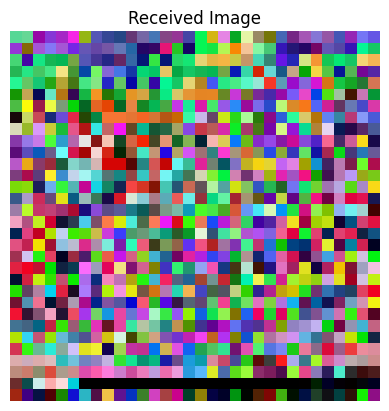

In [158]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import time
from comms_lib.pluto import Pluto
image_path = Path("../files/image.jpg")
print(image_path)
output_path = Path("../files/received.jpg")
sample_rate = 1e6
carrier_freq = 913e6
symbol_rate = 1e4 
samples_per_symbol = int(sample_rate // symbol_rate)
sdr.sample_rate = int(sample_rate)
sdr.rx_rf_bandwidth = int(sample_rate)
sdr.tx_rf_bandwidth = int(sample_rate)
sdr.rx_lo = int(carrier_freq)
sdr.tx_lo = int(carrier_freq)
sdr.gain_control_mode = 'manual'
sdr.rx_hardwaregain = 30
sdr.tx_hardwaregain = 0
def image_to_bits(image_path):
    img = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    img = cv2.resize(img, (32, 32))
    img_bytes = img.flatten().tobytes()
    bits = np.unpackbits(np.frombuffer(img_bytes, dtype=np.uint8))
    return bits, img.shape
def bpsk_modulate(bits, samples_per_symbol):
    symbols = 2 * bits - 1 
    return np.repeat(symbols, samples_per_symbol).astype(np.float32)
def bpsk_demodulate(rx_signal, samples_per_symbol):
    symbols = rx_signal[::samples_per_symbol]
    bits = (symbols > 0).astype(np.uint8)
    return bits
def bits_to_image(bits, shape):
    required_bits = np.prod(shape) * 8
    if len(bits) < required_bits:
        bits = np.pad(bits, (0, required_bits - len(bits)), 'constant')
    elif len(bits) > required_bits:
        bits = bits[:required_bits]
    byte_array = np.packbits(bits)
    img = np.frombuffer(byte_array, dtype=np.uint8)[:np.prod(shape)]
    return img.reshape(shape)
print("Encoding image...")
bits, shape = image_to_bits(image_path)
tx_signal = bpsk_modulate(bits, samples_per_symbol)
print("Transmitting...")
sdr.tx(tx_signal)
print("Receiving...")
rx_signal_complex = sdr.rx()
rx_signal = np.real(rx_signal_complex)  # Extract only real part
print(f"RX signal power: {np.mean(rx_signal**2)}")
rx_bits = bpsk_demodulate(rx_signal, samples_per_symbol)
rx_bits = rx_bits[:len(bits)]
if len(rx_bits) < len(bits):
    rx_bits = np.pad(rx_bits, (0, len(bits) - len(rx_bits)), 'constant')
print("Reconstructing image...")
received_img = bits_to_image(rx_bits, shape)
cv2.imwrite(str(output_path), received_img)
plt.imshow(cv2.cvtColor(received_img, cv2.COLOR_BGR2RGB))
plt.title("Received Image")
plt.axis('off')
plt.show()

In [150]:
tx_signal

array([255., 255., 255., ..., 255., 255., 255.],
      shape=(2457600,), dtype=float32)

In [149]:
rx_signal

array([242., 241., 240., ...,   0.,   0.,   0.], shape=(2457600,))